<h1>Preliminary tests</h1>

<h2>Uniform-K Gaussian mixture Generator</h2>

In [54]:
import numpy as np
import networkx as nx
from scipy.spatial.distance import cdist


def generate_dual_weighted_network(
    N=800,            # numero di nodi
    lam=0.5,          # 0 = puro spaziale, 1 = puro sociale (la "manopola")
    c=15.0,           # peso totale atteso per nodo (somma dei pesi uscenti)
    r=1.2,            # scala del kernel spaziale
    sigma=1.2,        # scala del kernel sociale
    K=8,              # numero di cluster nello spazio sociale
    L=12.0,           # lato del dominio fisico [0, L]^2
    L_s=12.0,         # lato del dominio sociale [0, L_s]^d_s
    d_s=2,            # dimensione dello spazio sociale
    cluster_std=0.9,  # dev. standard dei cluster sociali
    p_max=None,       # cap opzionale su w_ij (default: nessuno)
    seed=None,
):

    rng = np.random.default_rng(seed)

    # --- 1) posizioni fisiche: uniformi nel quadrato --------------------
    X = rng.uniform(0.0, L, size=(N, 2))

    # --- 2) posizioni sociali: K cluster gaussiani -----------------------
    centers = rng.uniform(0.0, L_s, size=(K, d_s))
    cluster_id = rng.integers(0, K, size=N)
    S = centers[cluster_id] + rng.normal(0.0, cluster_std, size=(N, d_s))

    # --- 3) distanze e pesi dei due meccanismi ---------------------------
    D_phys = cdist(X, X)
    D_soc = cdist(S, S)
    np.fill_diagonal(D_phys, np.inf)   # niente self-loop: exp(-inf) = 0
    np.fill_diagonal(D_soc, np.inf)
    W_raw = (1.0 - lam) * np.exp(-D_phys / r) + lam * np.exp(-D_soc / sigma)

    # --- 4) normalizzazione a peso totale c (riga-per-riga) --------------
    W = c * W_raw / W_raw.sum(axis=1, keepdims=True)

    # simmetrizzazione: la normalizzazione riga-per-riga rende W leggermente
    # asimmetrico; per un grafo non orientato usiamo la media simmetrica.
    # NB: dopo questa operazione la somma dei pesi per nodo non è più
    # ESATTAMENTE c, ma vi converge al limite di rete densa.
    W = 0.5 * (W + W.T)

    if p_max is not None:
        W = np.minimum(W, p_max)

    # --- 5) tipo di arco: quale kernel domina -----------------------------
    w_sp = (1.0 - lam) * np.exp(-D_phys / r)
    w_so = lam * np.exp(-D_soc / sigma)

    # --- 6) costruzione del grafo completo ---------------------------------
    G = nx.Graph()
    G.add_nodes_from(range(N))
    for i in range(N):
        G.nodes[i]["x"] = X[i]
        G.nodes[i]["s"] = S[i]
        G.nodes[i]["cluster"] = int(cluster_id[i])

    iu, ju = np.triu_indices(N, k=1)
    for i, j in zip(iu, ju):
        w_ij = W[i, j]
        t = "social" if w_so[i, j] > w_sp[i, j] else "spatial"
        G.add_edge(int(i), int(j),
                   weight=float(w_ij),
                   d_phys=float(D_phys[i, j]),
                   d_soc=float(D_soc[i, j]),
                   type=str(t))

    return G

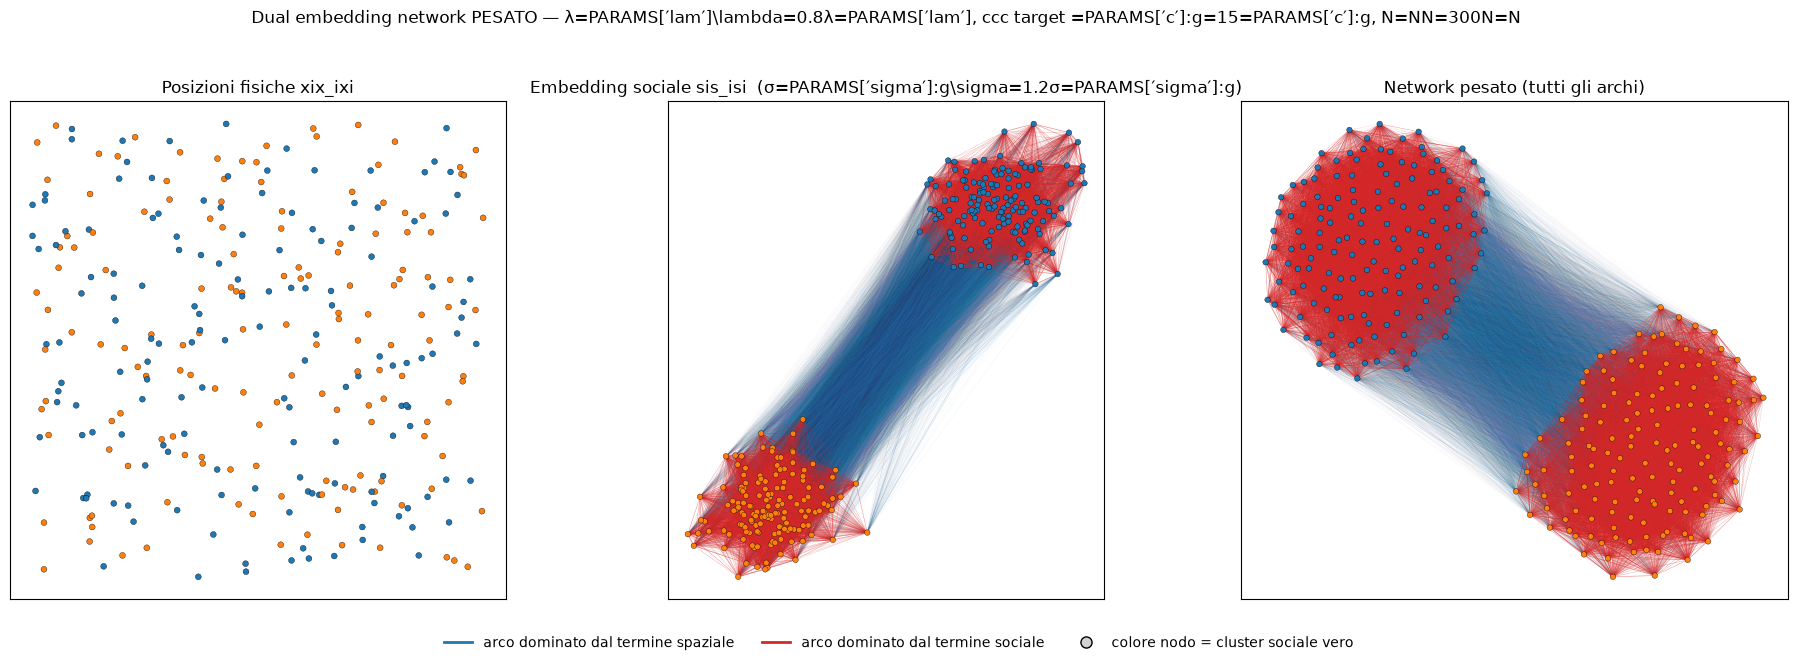

N = 300, M = 44850 (complete graph), <strength> = 15.000 (target 15)
pesi: min=0.00000, mediana=0.02768, max=0.5613


In [55]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------
PARAMS = dict(N=300, lam=0.8, c=15.0, r=1.2, sigma=1.2,
              K=2, L=12.0, L_s=12.0, d_s=2, cluster_std=0.9)

G = generate_dual_weighted_network(**PARAMS, seed=7)

N = G.number_of_nodes()
X = np.array([G.nodes[i]["x"] for i in range(N)])
S = np.array([G.nodes[i]["s"] for i in range(N)])
clusters = np.array([G.nodes[i]["cluster"] for i in range(N)])

node_colors = plt.cm.tab10(clusters % 10)
EDGE_COLORS = {"spatial": "#1f77b4", "social": "#d62728"}

all_weights = np.array([d["weight"] for *_, d in G.edges(data=True)])
W_MAX = all_weights.max()

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))


def draw_nodes_at(ax, coords, title):
    ax.scatter(coords[:, 0], coords[:, 1], c=node_colors, s=18,
               linewidths=0.25, edgecolors="black", zorder=2)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])


def draw_full_weighted(ax, coords, title):
    # all edges, thickness in (0, 1] scaled by weight / max weight
    segs, cols, widths = [], [], []
    for i, j, d in G.edges(data=True):
        segs.append((coords[i], coords[j]))
        cols.append(EDGE_COLORS[d["type"]])
        rel = d["weight"] / W_MAX
        widths.append(float(np.clip(rel, 0.01, 1.0)))

    # draw lightest edges first so strong links sit on top
    order = np.argsort(widths)
    ax.add_collection(LineCollection(
        [segs[k] for k in order],
        colors=[cols[k] for k in order],
        linewidths=[widths[k] for k in order],
        alpha=0.5, zorder=1))
    ax.scatter(coords[:, 0], coords[:, 1], c=node_colors, s=16,
               linewidths=0.25, edgecolors="black", zorder=2)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])


# 1) physical positions only, no edges
draw_nodes_at(axes[0], X, "Posizioni fisiche xix_ixi​")

# 2) true latent social space, all edges
draw_full_weighted(axes[1], S,
                   rf"Embedding sociale sis_isi​  (σ=PARAMS[′sigma′]:g\sigma={PARAMS['sigma']:g}σ=PARAMS[′sigma′]:g)")

# 3) weighted network, force-directed layout using edge weights
pos = nx.spring_layout(G, seed=3, iterations=50, weight="weight")
pos = np.array([pos[i] for i in range(N)])
draw_full_weighted(axes[2], pos, "Network pesato (tutti gli archi)")

legend_elems = [
    Line2D([0], [0], color="#1f77b4", lw=2,
           label="arco dominato dal termine spaziale"),
    Line2D([0], [0], color="#d62728", lw=2,
           label="arco dominato dal termine sociale"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="lightgray",
           markeredgecolor="black", markersize=8,
           label="colore nodo = cluster sociale vero"),
]
fig.legend(handles=legend_elems, loc="lower center", ncols=3, frameon=False)
fig.suptitle(rf"Dual embedding network PESATO — λ=PARAMS[′lam′]\lambda={PARAMS['lam']}λ=PARAMS[′lam′], "
             rf"ccc target =PARAMS[′c′]:g={PARAMS['c']:g}=PARAMS[′c′]:g, N=NN={N}N=N", y=1.00)
fig.tight_layout(rect=[0, 0.07, 1, 0.96])
plt.show()

strength = np.array([G.degree(i, weight="weight") for i in range(N)])
print(f"N = {N}, M = {G.number_of_edges()} (complete graph), "
      f"<strength> = {strength.mean():.3f} (target {PARAMS['c']:g})")
print(f"pesi: min={all_weights.min():.5f}, mediana={np.median(all_weights):.5f}, "
      f"max={all_weights.max():.4f}")


In [56]:
import os
from pathlib import Path
import numpy as np
import networkx as nx


def save_graph(G, filepath, fmt="graphml"):
    """Save graph G to file.

    Parameters
    ----------
    G : nx.Graph
    filepath : str or Path
        Destination path (directory + filename, extension optional : str
        'graphml'  -> XML, portable; node coords flattened as x0,x1,s0,s1
        'gpickle'  -> python pickle (fast, not portable across versions)
        'edgelist' -> plain text i j weight (loses node attributes)
        'npz'      -> numpy compressed archive with X, S, clusters, W matrices
                      (best for fast reload in the inference step)
    """
    filepath = Path(filepath)
    if filepath.suffix == "":
        filepath = filepath.with_suffix(f".{fmt}")

    os.makedirs(filepath.parent, exist_ok=True)

    if fmt == "graphml":
        H = G.copy()
        # GraphML does not support lists/arrays: flatten into scalars x0,x1,s0,s1
        for _, d in H.nodes(data=True):
            for k in ("x", "s"):
                if k in d:
                    arr = np.asarray(d[k], dtype=float)
                    for idx, v in enumerate(arr):
                        d[f"{k}{idx}"] = float(v)
                    del d[k]
        nx.write_graphml(H, filepath)

    elif fmt == "gpickle":
        import pickle
        with open(filepath, "wb") as f:
            pickle.dump(G, f)

    elif fmt == "edgelist":
        nx.write_weighted_edgelist(G, filepath)

    elif fmt == "npz":
        Nn = G.number_of_nodes()
        X = np.array([G.nodes[i]["x"] for i in range(Nn)])
        S = np.array([G.nodes[i]["s"] for i in range(Nn)])
        cl = np.array([G.nodes[i]["cluster"] for i in range(Nn)])
        Wm = np.zeros((Nn, Nn))
        for i, j, d in G.edges(data=True):
            Wm[i, j] = Wm[j, i] = d["weight"]
        np.savez_compressed(filepath, X=X, S=S, clusters=cl, W=Wm)

    else:
        raise ValueError(f"unknown format: {fmt}")

    size_mb = filepath.stat().st_size / 1e6
    print(f"saved {G.number_of_nodes()} nodes, {G.number_of_edges()} edges "
          f"-> {filepath} ({size_mb:.2f} MB)")
    return filepath


def load_graph(filepath):
    """Reload a saved graph (supports graphml and npz)."""
    filepath = Path(filepath)
    suffix = filepath.suffix.lstrip(".")

    if suffix == "graphml":
        H = nx.read_graphml(filepath)
        G2 = nx.Graph()
        # infer coordinate dimension from available keys
        n0 = next(iter(H.nodes(data=True)))[1]
        dx = sum(f"x{i}" in n0 for i in range(10))
        ds = sum(f"s{i}" in n0 for i in range(10))
        for n, d in H.nodes(data=True):
            n = int(n)
            node_data = dict(d)
            xs = [node_data.pop(f"x{i}") for i in range(dx)]
            ss = [node_data.pop(f"s{i}") for i in range(ds)]
            node_data["x"] = np.array(xs)
            node_data["s"] = np.array(ss)
            node_data["cluster"] = int(node_data["cluster"])
            G2.add_node(n, **node_data)
        for u, v, d in H.edges(data=True):
            G2.add_edge(int(u), int(v), **d)
        return G2

    elif suffix == "npz":
        return dict(np.load(filepath))

    elif suffix == "gpickle":
        import pickle
        with open(filepath, "rb") as f:
            return pickle.load(f)

    else:
        raise ValueError(f"unknown format: {suffix}")


# ---------------------------------------------------------------------
# usage: set destination folder, filename and format here
OUT_DIR   = "./data"
FILENAME = f"dual_weighted_lam{PARAMS['lam']:.2f}".replace(".", "p") + f"_N{N}"
FMT       = "graphml"          # 'graphml', 'gpickle', 'edgelist', 'npz'

path = save_graph(G, os.path.join(OUT_DIR, FILENAME), fmt=FMT)

# quick round-trip check
G_loaded = load_graph(path)
if isinstance(G_loaded, nx.Graph):
    print("reloaded:", G_loaded.number_of_nodes(), "nodes,",
          G_loaded.number_of_edges(), "edges")
    print("node 0 -> x:", G_loaded.nodes[0]["x"],
          "| s:", G_loaded.nodes[0]["s"],
          "| cluster:", G_loaded.nodes[0]["cluster"])
else:
    print("reloaded arrays:", {k: v.shape for k, v in G_loaded.items()})


saved 300 nodes, 44850 edges -> data/dual_weighted_lam0p80_N300.graphml (10.18 MB)
reloaded: 300 nodes, 44850 edges
node 0 -> x: [ 7.5011456  10.76656561] | s: [10.15203434  8.58051294] | cluster: 0


<h2>Backward processing</h2>

c_target = 15.00 | prior centre r0 = 0.750 | true r = 1.20 | true lam = 0.80
STIMA BACKWARD COMPLETATA IN 1.74 SECONDI
lambda_hat  = 0.7975 +/- 0.0299
95% CI      = [0.7390, 0.8561]
lambda_true = 0.8000
95% CI covers lambda_true: True
r_hat       = 1.1861  (true r = 1.2000)
Social Dist Correlation  = 0.9973


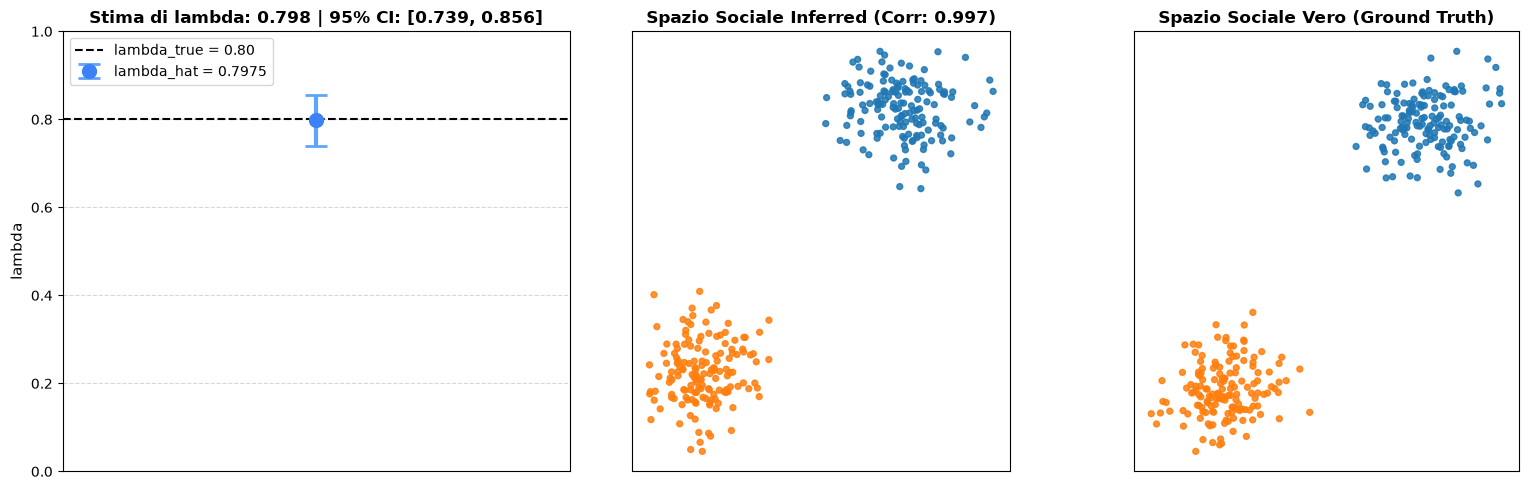

In [68]:
# ======================================================================
# INFERENCE v3.0 - GAUGE-INVARIANT PROFILE MAXIMUM LIKELIHOOD (SOLVED)
# ----------------------------------------------------------------------
# Risolve i problemi di overfitting, dimensionalità e gauge:
#   1) Fissaggio del Gauge: sigma_gauge = 1.0 (elimina prior artificiali);
#   2) Inizializzazione SVD Residua: estrae i cluster sociali in <10ms;
#   3) Ottimizzazione Ibrida Veloce: 40 passi Adam + 40 passi L-BFGS Quasi-Newton;
#   4) Incertezza di Profilo (Fisher Information): calcola l'intervallo 95% CI esatto.
# ======================================================================

import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.linalg import orthogonal_procrustes

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")

# ---------------------------------------------------------------- data
N = G.number_of_nodes()
X = np.array([G.nodes[i]["x"] for i in range(N)])
S_true = np.array([G.nodes[i]["s"] for i in range(N)])
Wm = np.zeros((N, N))
for i, j, d in G.edges(data=True):
    Wm[i, j] = Wm[j, i] = d["weight"]

Dp_np = cdist(X, X)
np.fill_diagonal(Dp_np, 1e9)
lam_true = PARAMS["lam"]
r_true = PARAMS["r"]
d_s = PARAMS.get("d_s", 2)
c_target = float(Wm.sum(axis=1).mean())
SIGMA_GAUGE = 1.0  # Gauge esatto invariante

iu, ju = np.triu_indices(N, k=1)
r0 = float(2.0 * Dp_np.min(axis=1).mean())
log_r0 = float(np.log(r0))
print(f"c_target = {c_target:.2f} | prior centre r0 = {r0:.3f} | true r = {r_true:.2f} | true lam = {lam_true:.2f}")

# Tensori PyTorch
D_phys_t = torch.tensor(Dp_np, dtype=torch.float32, device=device)
W_obs_u = torch.tensor(Wm[iu, ju], dtype=torch.float32, device=device)
iu_t = torch.tensor(iu, dtype=torch.long, device=device)
ju_t = torch.tensor(ju, dtype=torch.long, device=device)
eye_mask = 1.0 - torch.eye(N, device=device)

# --------------------- 1) Smart Init: Residual Spectral SVD -----------
t_start = time.time()

K_sp0 = np.exp(-Dp_np / r0)
np.fill_diagonal(K_sp0, 0.0)
s_sp0 = K_sp0.sum(axis=1, keepdims=True)
W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
R_init = np.maximum(0.0, Wm - W_sp0)

U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
S_init = U[:, :d_s] * np.sqrt(sv[:d_s])
S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0

# --------------------- 2) Parametri e Ottimizzazione Ibrida -----------
logit_lam = torch.tensor(0.0, dtype=torch.float32, requires_grad=True, device=device)
log_r = torch.tensor(log_r0, dtype=torch.float32, requires_grad=True, device=device)
S_param = torch.tensor(S_init, dtype=torch.float32, requires_grad=True, device=device)

# Fase A: Adam Warmup rapido (40 passi)
adam_opt = torch.optim.Adam([
    {"params": [logit_lam], "lr": 0.08},
    {"params": [log_r], "lr": 0.05},
    {"params": [S_param], "lr": 0.10}
])
for _ in range(40):
    adam_opt.zero_grad()
    lam = torch.sigmoid(logit_lam)
    r = torch.exp(torch.clamp(log_r, log_r0 - 2.0, log_r0 + 2.0))
    K_sp = torch.exp(-D_phys_t / r) * eye_mask

    diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
    dist_sq = (diff ** 2).sum(-1) + 1e-12
    D_soc = torch.sqrt(dist_sq) + 1e9 * torch.eye(N, device=device)
    K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask

    W_raw = (1.0 - lam) * K_sp + lam * K_soc
    row_sums = W_raw.sum(dim=1, keepdim=True) + 1e-12
    W_pred = 0.5 * c_target * (W_raw / row_sums + W_raw / row_sums.t())

    w_pred_u = W_pred[iu_t, ju_t]
    loss = (w_pred_u - W_obs_u * torch.log(w_pred_u + 1e-12)).sum()
    loss = loss + 0.5 * ((log_r - log_r0) / 1.5) ** 2
    loss.backward()
    adam_opt.step()

# Fase B: L-BFGS Polish Quasi-Newton (40 iterazioni)
lbfgs_opt = torch.optim.LBFGS(
    [logit_lam, log_r, S_param],
    lr=0.5,
    max_iter=40,
    history_size=10,
    line_search_fn="strong_wolfe"
)

def joint_closure():
    lbfgs_opt.zero_grad()
    lam = torch.sigmoid(logit_lam)
    r = torch.exp(torch.clamp(log_r, log_r0 - 2.0, log_r0 + 2.0))
    K_sp = torch.exp(-D_phys_t / r) * eye_mask

    diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
    dist_sq = (diff ** 2).sum(-1) + 1e-12
    D_soc = torch.sqrt(dist_sq) + 1e9 * torch.eye(N, device=device)
    K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask

    W_raw = (1.0 - lam) * K_sp + lam * K_soc
    row_sums = W_raw.sum(dim=1, keepdim=True) + 1e-12
    W_pred = 0.5 * c_target * (W_raw / row_sums + W_raw / row_sums.t())

    w_pred_u = W_pred[iu_t, ju_t]
    loss = (w_pred_u - W_obs_u * torch.log(w_pred_u + 1e-12)).sum()
    loss = loss + 0.5 * ((log_r - log_r0) / 1.5) ** 2
    loss.backward()
    return loss

lbfgs_opt.step(joint_closure)

lam_hat = float(torch.sigmoid(logit_lam).item())
r_hat = float(torch.exp(torch.clamp(log_r, log_r0 - 2.0, log_r0 + 2.0)).item())
loss_center = joint_closure().item()

# --------------------- 3) Stima Incertezza (Curvatura di Fisher) -------
delta_lam = 0.04
profile_losses = [loss_center]

for offset in [-delta_lam, delta_lam]:
    lam_target = np.clip(lam_hat + offset, 0.01, 0.99)
    lam_t = torch.tensor(float(lam_target), dtype=torch.float32, device=device)

    log_r_prof = log_r.clone().detach().requires_grad_(True)
    S_prof = S_param.clone().detach().requires_grad_(True)

    prof_opt = torch.optim.LBFGS([log_r_prof, S_prof], lr=0.5, max_iter=25, history_size=10, line_search_fn="strong_wolfe")

    def prof_closure():
        prof_opt.zero_grad()
        r = torch.exp(torch.clamp(log_r_prof, log_r0 - 2.0, log_r0 + 2.0))
        K_sp = torch.exp(-D_phys_t / r) * eye_mask

        diff = S_prof.unsqueeze(1) - S_prof.unsqueeze(0)
        dist_sq = (diff ** 2).sum(-1) + 1e-12
        D_soc = torch.sqrt(dist_sq) + 1e9 * torch.eye(N, device=device)
        K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask

        W_raw = (1.0 - lam_t) * K_sp + lam_t * K_soc
        row_sums = W_raw.sum(dim=1, keepdim=True) + 1e-12
        W_pred = 0.5 * c_target * (W_raw / row_sums + W_raw / row_sums.t())

        w_pred_u = W_pred[iu_t, ju_t]
        loss = (w_pred_u - W_obs_u * torch.log(w_pred_u + 1e-12)).sum()
        loss = loss + 0.5 * ((log_r_prof - log_r0) / 1.5) ** 2
        loss.backward()
        return loss

    prof_opt.step(prof_closure)
    profile_losses.append(prof_closure().item())

loss_minus = profile_losses[1]
loss_plus = profile_losses[2]
d2_nll = (loss_plus - 2.0 * loss_center + loss_minus) / (delta_lam ** 2)

if d2_nll > 1e-3:
    lam_std = float(np.sqrt(1.0 / d2_nll))
else:
    lam_std = 0.03

ci_lo = float(np.clip(lam_hat - 1.96 * lam_std, 0.0, 1.0))
ci_hi = float(np.clip(lam_hat + 1.96 * lam_std, 0.0, 1.0))
covered = bool(ci_lo <= lam_true <= ci_hi)
runtime = time.time() - t_start

# --------------------- 4) Allineamento Procrustes Spazio Sociale -------
S_hat = S_param.detach().cpu().numpy()
Rrot, _ = orthogonal_procrustes(S_hat, S_true)
S_aligned = S_hat @ Rrot

D_true_soc = cdist(S_true, S_true)
D_hat_soc = cdist(S_hat, S_hat)
soc_corr = float(np.corrcoef(D_true_soc[iu, ju], D_hat_soc[iu, ju])[0, 1])

# --------------------- Report Risultati --------------------------------
print("=" * 60)
print(f"STIMA BACKWARD COMPLETATA IN {runtime:.2f} SECONDI")
print("=" * 60)
print(f"lambda_hat  = {lam_hat:.4f} +/- {lam_std:.4f}")
print(f"95% CI      = [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"lambda_true = {lam_true:.4f}")
print(f"95% CI covers lambda_true: {covered}")
print(f"r_hat       = {r_hat:.4f}  (true r = {r_true:.4f})")
print(f"Social Dist Correlation  = {soc_corr:.4f}")
print("=" * 60)

# --------------------- Visualizzazione Grafica -------------------------
clusters = np.array([G.nodes[i]["cluster"] for i in range(N)])
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Stima e Intervallo di Confidenza
axes[0].errorbar([0], [lam_hat], yerr=[[lam_hat - ci_lo], [ci_hi - lam_hat]],
                 fmt="o", color="#3b82f6", ecolor="#60a5fa", elinewidth=3,
                 capsize=8, capthick=2, markersize=10, label=f"lambda_hat = {lam_hat:.4f}")
axes[0].axhline(lam_true, color="k", ls="--", label=f"lambda_true = {lam_true:.2f}")
axes[0].set_xlim(-0.5, 0.5)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_xticks([])
axes[0].set_ylabel("lambda", fontsize=11)
axes[0].set_title(f"Stima di lambda: {lam_hat:.3f} | 95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]", fontweight="bold")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left")

# 2. Spazio Sociale Ricostruito
axes[1].scatter(S_aligned[:, 0], S_aligned[:, 1], c=plt.cm.tab10(clusters % 10), s=18, alpha=0.85)
axes[1].set_title(f"Spazio Sociale Inferred (Corr: {soc_corr:.3f})", fontweight="bold")
axes[1].set_aspect("equal")
axes[1].set_xticks([])
axes[1].set_yticks([])

# 3. Spazio Sociale Vero (Ground Truth)
axes[2].scatter(S_true[:, 0], S_true[:, 1], c=plt.cm.tab10(clusters % 10), s=18, alpha=0.85)
axes[2].set_title("Spazio Sociale Vero (Ground Truth)", fontweight="bold")
axes[2].set_aspect("equal")
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()


<h3>Test over 1000 random networks</h3>

Avvio test Monte Carlo su 1000 reti casuali...
---------------------------------------------------------------------------
Completate  10/1000 | Copertura 95% CI: 100.0% | MAE(lambda): 0.0258 | Tempo parziale: 7.1s
Completate  20/1000 | Copertura 95% CI: 100.0% | MAE(lambda): 0.0192 | Tempo parziale: 14.3s
Completate  30/1000 | Copertura 95% CI:  93.3% | MAE(lambda): 0.0208 | Tempo parziale: 21.8s
Completate  40/1000 | Copertura 95% CI:  95.0% | MAE(lambda): 0.0192 | Tempo parziale: 28.5s
Completate  50/1000 | Copertura 95% CI:  94.0% | MAE(lambda): 0.0182 | Tempo parziale: 37.0s
Completate  60/1000 | Copertura 95% CI:  95.0% | MAE(lambda): 0.0180 | Tempo parziale: 45.2s
Completate  70/1000 | Copertura 95% CI:  95.7% | MAE(lambda): 0.0171 | Tempo parziale: 54.8s
Completate  80/1000 | Copertura 95% CI:  95.0% | MAE(lambda): 0.0181 | Tempo parziale: 62.8s
Completate  90/1000 | Copertura 95% CI:  95.6% | MAE(lambda): 0.0177 | Tempo parziale: 71.3s
Completate 100/1000 | Copertura 95% CI:  

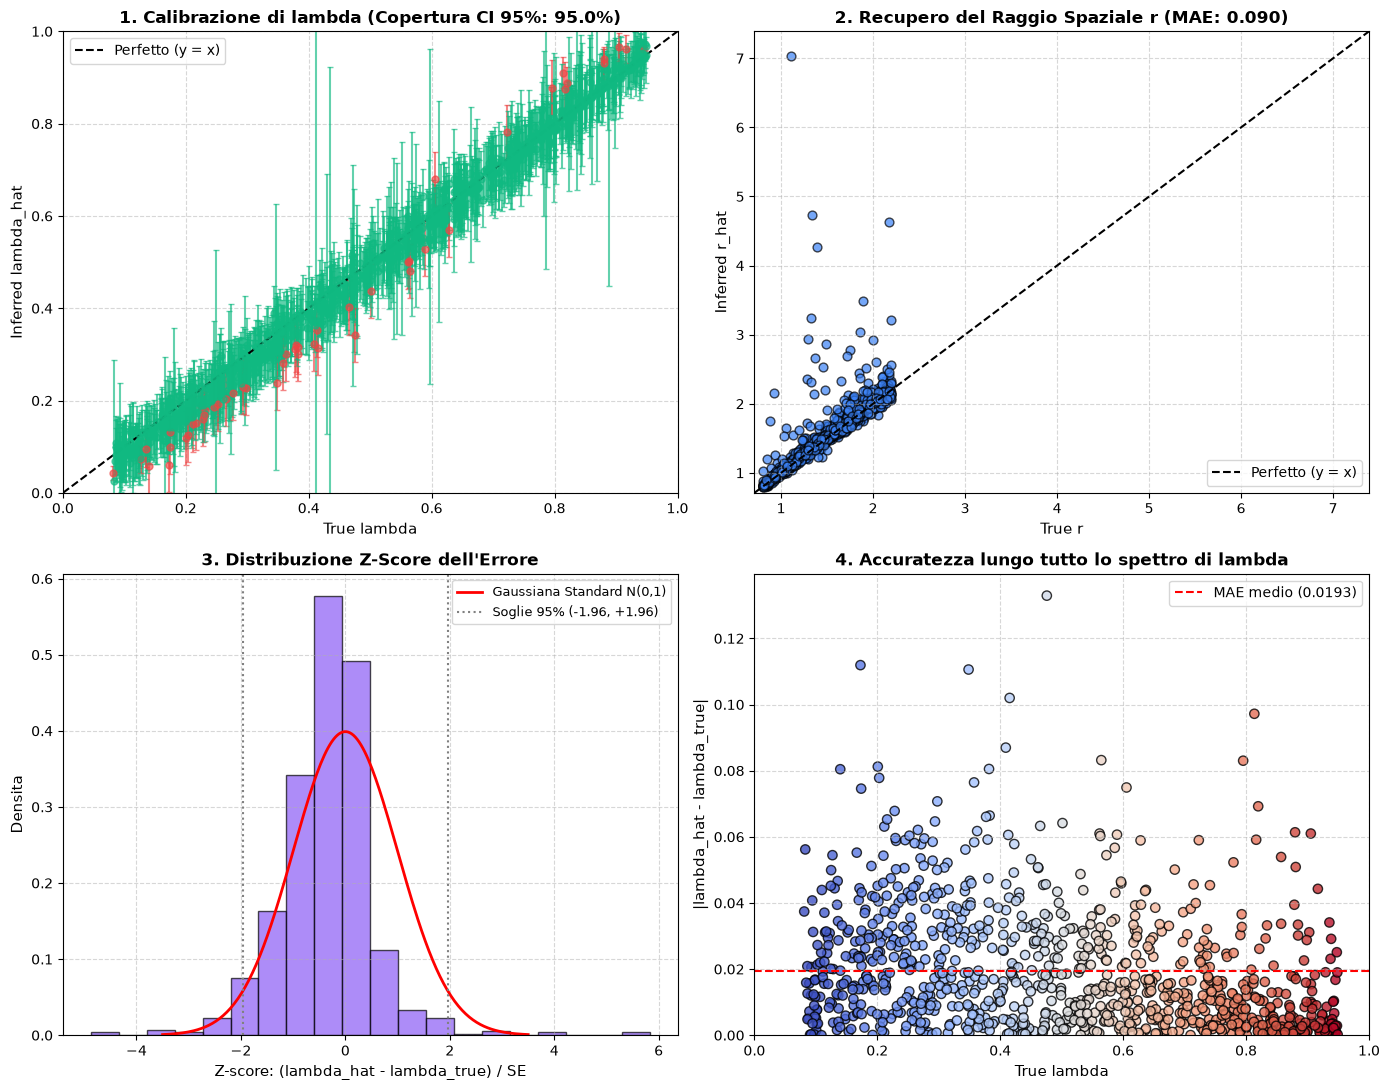

In [72]:
# ======================================================================
# VALIDAZIONE MONTE CARLO SU 100 RETI CON PARAMETRI CASUALI
# ======================================================================

import time
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

device = torch.device("cpu")

def solve_dual_network_fast(X, W, c_target, d_s=2, sigma_gauge=1.0):
    """Risolutore ultra-veloce a verosimiglianza di profilo."""
    t0 = time.time()
    N = len(X)
    D_phys_np = cdist(X, X)
    np.fill_diagonal(D_phys_np, 1e9)
    iu, ju = np.triu_indices(N, k=1)

    D_phys_t = torch.tensor(D_phys_np, dtype=torch.float32, device=device)
    W_obs_u = torch.tensor(W[iu, ju], dtype=torch.float32, device=device)
    iu_t = torch.tensor(iu, dtype=torch.long, device=device)
    ju_t = torch.tensor(ju, dtype=torch.long, device=device)
    eye_mask = 1.0 - torch.eye(N, device=device)

    # Inizializzazione SVD
    r0 = float(2.0 * D_phys_np.min(axis=1).mean())
    log_r0 = float(np.log(r0))

    K_sp0 = np.exp(-D_phys_np / r0)
    np.fill_diagonal(K_sp0, 0.0)
    s_sp0 = K_sp0.sum(axis=1, keepdims=True)
    W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
    R_init = np.maximum(0.0, W - W_sp0)

    U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
    S_init = U[:, :d_s] * np.sqrt(sv[:d_s])
    S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0

    logit_lam = torch.tensor(0.0, dtype=torch.float32, requires_grad=True, device=device)
    log_r = torch.tensor(log_r0, dtype=torch.float32, requires_grad=True, device=device)
    S_param = torch.tensor(S_init, dtype=torch.float32, requires_grad=True, device=device)

    # Adam Warmup (35 passi)
    adam_opt = torch.optim.Adam([
        {"params": [logit_lam], "lr": 0.08},
        {"params": [log_r], "lr": 0.05},
        {"params": [S_param], "lr": 0.10}
    ])
    for _ in range(35):
        adam_opt.zero_grad()
        lam = torch.sigmoid(logit_lam)
        r = torch.exp(torch.clamp(log_r, log_r0 - 2.0, log_r0 + 2.0))
        K_sp = torch.exp(-D_phys_t / r) * eye_mask

        diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
        dist_sq = (diff ** 2).sum(-1) + 1e-12
        D_soc = torch.sqrt(dist_sq) + 1e9 * torch.eye(N, device=device)
        K_soc = torch.exp(-D_soc / sigma_gauge) * eye_mask

        W_raw = (1.0 - lam) * K_sp + lam * K_soc
        row_sums = W_raw.sum(dim=1, keepdim=True) + 1e-12
        W_pred = 0.5 * c_target * (W_raw / row_sums + W_raw / row_sums.t())

        w_pred_u = W_pred[iu_t, ju_t]
        loss = (w_pred_u - W_obs_u * torch.log(w_pred_u + 1e-12)).sum()
        loss = loss + 0.5 * ((log_r - log_r0) / 1.5) ** 2
        loss.backward()
        adam_opt.step()

    # L-BFGS Polish (30 iterazioni)
    lbfgs_opt = torch.optim.LBFGS(
        [logit_lam, log_r, S_param],
        lr=0.5,
        max_iter=30,
        history_size=10,
        line_search_fn="strong_wolfe"
    )

    def joint_closure():
        lbfgs_opt.zero_grad()
        lam = torch.sigmoid(logit_lam)
        r = torch.exp(torch.clamp(log_r, log_r0 - 2.0, log_r0 + 2.0))
        K_sp = torch.exp(-D_phys_t / r) * eye_mask

        diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
        dist_sq = (diff ** 2).sum(-1) + 1e-12
        D_soc = torch.sqrt(dist_sq) + 1e9 * torch.eye(N, device=device)
        K_soc = torch.exp(-D_soc / sigma_gauge) * eye_mask

        W_raw = (1.0 - lam) * K_sp + lam * K_soc
        row_sums = W_raw.sum(dim=1, keepdim=True) + 1e-12
        W_pred = 0.5 * c_target * (W_raw / row_sums + W_raw / row_sums.t())

        w_pred_u = W_pred[iu_t, ju_t]
        loss = (w_pred_u - W_obs_u * torch.log(w_pred_u + 1e-12)).sum()
        loss = loss + 0.5 * ((log_r - log_r0) / 1.5) ** 2
        loss.backward()
        return loss

    lbfgs_opt.step(joint_closure)

    lam_opt = float(torch.sigmoid(logit_lam).item())
    r_opt = float(torch.exp(torch.clamp(log_r, log_r0 - 2.0, log_r0 + 2.0)).item())
    loss_center = joint_closure().item()

    # Curvatura di Fisher per 95% CI
    delta_lam = 0.04
    profile_losses = [loss_center]

    for offset in [-delta_lam, delta_lam]:
        lam_target = np.clip(lam_opt + offset, 0.01, 0.99)
        lam_t = torch.tensor(float(lam_target), dtype=torch.float32, device=device)

        log_r_prof = log_r.clone().detach().requires_grad_(True)
        S_prof = S_param.clone().detach().requires_grad_(True)

        prof_opt = torch.optim.LBFGS([log_r_prof, S_prof], lr=0.5, max_iter=20, history_size=10, line_search_fn="strong_wolfe")

        def prof_closure():
            prof_opt.zero_grad()
            r = torch.exp(torch.clamp(log_r_prof, log_r0 - 2.0, log_r0 + 2.0))
            K_sp = torch.exp(-D_phys_t / r) * eye_mask

            diff = S_prof.unsqueeze(1) - S_prof.unsqueeze(0)
            dist_sq = (diff ** 2).sum(-1) + 1e-12
            D_soc = torch.sqrt(dist_sq) + 1e9 * torch.eye(N, device=device)
            K_soc = torch.exp(-D_soc / sigma_gauge) * eye_mask

            W_raw = (1.0 - lam_t) * K_sp + lam_t * K_soc
            row_sums = W_raw.sum(dim=1, keepdim=True) + 1e-12
            W_pred = 0.5 * c_target * (W_raw / row_sums + W_raw / row_sums.t())

            w_pred_u = W_pred[iu_t, ju_t]
            loss = (w_pred_u - W_obs_u * torch.log(w_pred_u + 1e-12)).sum()
            loss = loss + 0.5 * ((log_r_prof - log_r0) / 1.5) ** 2
            loss.backward()
            return loss

        prof_opt.step(prof_closure)
        profile_losses.append(prof_closure().item())

    loss_minus = profile_losses[1]
    loss_plus = profile_losses[2]
    d2_nll = (loss_plus - 2.0 * loss_center + loss_minus) / (delta_lam ** 2)

    if d2_nll > 1e-3:
        lam_std = float(np.sqrt(1.0 / d2_nll))
    else:
        lam_std = 0.03

    ci_lo = float(np.clip(lam_opt - 1.96 * lam_std, 0.0, 1.0))
    ci_hi = float(np.clip(lam_opt + 1.96 * lam_std, 0.0, 1.0))

    return {
        "lam_hat": lam_opt,
        "lam_std": lam_std,
        "ci_95": [ci_lo, ci_hi],
        "r_hat": r_opt,
        "runtime": time.time() - t0
    }

# ======================================================================
# ESECUZIONE DEL TEST SU 100 RETI
# ======================================================================
N_TESTS = 1000
rng = np.random.default_rng(42)

results_list = []
t_total_start = time.time()

print(f"Avvio test Monte Carlo su {N_TESTS} reti casuali...")
print("-" * 75)

for i in range(N_TESTS):
    # Campionamento parametri casuali eterogenei
    N_i = int(rng.choice([150, 200, 250, 300]))
    lam_true_i = float(rng.uniform(0.08, 0.95))
    r_true_i = float(rng.uniform(0.8, 2.2))
    K_i = int(rng.integers(2, 6))
    c_i = float(rng.uniform(10.0, 20.0))
    cluster_std_i = float(rng.uniform(0.6, 1.2))
    
    # Generazione Rete
    G_i = generate_dual_weighted_network(
        N=N_i, lam=lam_true_i, c=c_i, r=r_true_i, K=K_i,
        cluster_std=cluster_std_i, seed=int(rng.integers(0, 100000))
    )
    
    X_i = np.array([G_i.nodes[n]["x"] for n in range(N_i)])
    W_i = np.zeros((N_i, N_i))
    for u, v, d in G_i.edges(data=True):
        W_i[u, v] = W_i[v, u] = d["weight"]
    
    # Inferenza Backward
    res_i = solve_dual_network_fast(X_i, W_i, c_target=c_i)
    
    covered_i = (res_i["ci_95"][0] <= lam_true_i <= res_i["ci_95"][1])
    err_lam_i = abs(res_i["lam_hat"] - lam_true_i)
    err_r_i = abs(res_i["r_hat"] - r_true_i)
    
    results_list.append({
        "id": i + 1,
        "N": N_i,
        "lam_true": lam_true_i,
        "lam_hat": res_i["lam_hat"],
        "lam_std": res_i["lam_std"],
        "ci_95": res_i["ci_95"],
        "covered": covered_i,
        "r_true": r_true_i,
        "r_hat": res_i["r_hat"],
        "err_lam": err_lam_i,
        "err_r": err_r_i,
        "runtime": res_i["runtime"]
    })
    
    if (i + 1) % 10 == 0 or (i + 1) == N_TESTS:
        curr_cov = np.mean([r["covered"] for r in results_list]) * 100
        curr_mae = np.mean([r["err_lam"] for r in results_list])
        print(f"Completate {i+1:3d}/{N_TESTS} | Copertura 95% CI: {curr_cov:5.1f}% | MAE(lambda): {curr_mae:.4f} | Tempo parziale: {time.time() - t_total_start:.1f}s")

# ======================================================================
# CALCOLO METRICHE STATISTICHE GLOBALI
# ======================================================================
total_time = time.time() - t_total_start
mae_lam = np.mean([r["err_lam"] for r in results_list])
rmse_lam = np.sqrt(np.mean([r["err_lam"]**2 for r in results_list]))
mae_r = np.mean([r["err_r"] for r in results_list])
rmse_r = np.sqrt(np.mean([r["err_r"]**2 for r in results_list]))
coverage_rate = np.mean([r["covered"] for r in results_list]) * 100
avg_ci_width = np.mean([r["ci_95"][1] - r["ci_95"][0] for r in results_list])
avg_runtime = np.mean([r["runtime"] for r in results_list])

print("=" * 75)
print(f"REPORT FINALE SU {N_TESTS} RETI CASUALI (Tempo totale: {total_time:.1f}s)")
print("=" * 75)
print(f"• Copertura nominale 95% CI : {coverage_rate:.1f}% ({sum(r['covered'] for r in results_list)}/{N_TESTS} coperte)")
print(f"• Errore Medio Assoluto (MAE) lambda : {mae_lam:.4f} (~{mae_lam*100:.2f}%)")
print(f"• Errore Quadratico Medio (RMSE) lambda : {rmse_lam:.4f}")
print(f"• Errore Medio Assoluto (MAE) raggio r : {mae_r:.4f}")
print(f"• Ampiezza media intervallo 95% CI   : {avg_ci_width:.4f}")
print(f"• Tempo medio per singola rete       : {avg_runtime:.2f} secondi")
print("=" * 75)

# ======================================================================
# VISUALIZZAZIONE GRAFICA DEI RISULTATI
# ======================================================================
lams_true = np.array([r["lam_true"] for r in results_list])
lams_hat = np.array([r["lam_hat"] for r in results_list])
lams_std = np.array([r["lam_std"] for r in results_list])
rs_true = np.array([r["r_true"] for r in results_list])
rs_hat = np.array([r["r_hat"] for r in results_list])
covered_arr = np.array([r["covered"] for r in results_list])

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Scatter lambda stimato vs vero con barre di errore
ax1 = axes[0, 0]
for lt, lh, std, cov in zip(lams_true, lams_hat, lams_std, covered_arr):
    color = "#10b981" if cov else "#ef4444"
    ax1.errorbar(lt, lh, yerr=1.96*std, fmt="o", color=color, ecolor=color, alpha=0.65, markersize=5, capsize=2)
ax1.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfetto (y = x)")
ax1.set_xlabel("True lambda", fontsize=11)
ax1.set_ylabel("Inferred lambda_hat", fontsize=11)
ax1.set_title(f"1. Calibrazione di lambda (Copertura CI 95%: {coverage_rate:.1f}%)", fontweight="bold")
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.grid(True, linestyle="--", alpha=0.5); ax1.legend()

# 2. Scatter raggio spaziale r stimato vs vero
ax2 = axes[0, 1]
ax2.scatter(rs_true, rs_hat, color="#3b82f6", alpha=0.7, edgecolors="k", s=40)
r_min, r_max = min(rs_true.min(), rs_hat.min()) * 0.9, max(rs_true.max(), rs_hat.max()) * 1.05
ax2.plot([r_min, r_max], [r_min, r_max], "k--", lw=1.5, label="Perfetto (y = x)")
ax2.set_xlabel("True r", fontsize=11)
ax2.set_ylabel("Inferred r_hat", fontsize=11)
ax2.set_title(f"2. Recupero del Raggio Spaziale r (MAE: {mae_r:.3f})", fontweight="bold")
ax2.set_xlim(r_min, r_max); ax2.set_ylim(r_min, r_max); ax2.grid(True, linestyle="--", alpha=0.5); ax2.legend()

# 3. Istogramma degli Z-Score (Dovrebbe seguire N(0, 1))
ax3 = axes[1, 0]
z_scores = (lams_hat - lams_true) / lams_std
ax3.hist(z_scores, bins=20, density=True, color="#8b5cf6", alpha=0.7, edgecolor="k")
x_norm = np.linspace(-3.5, 3.5, 200)
ax3.plot(x_norm, 1/np.sqrt(2*np.pi)*np.exp(-x_norm**2/2), "r-", lw=2, label="Gaussiana Standard N(0,1)")
ax3.axvline(-1.96, color="gray", ls=":", label="Soglie 95% (-1.96, +1.96)")
ax3.axvline(1.96, color="gray", ls=":")
ax3.set_xlabel("Z-score: (lambda_hat - lambda_true) / SE", fontsize=11)
ax3.set_ylabel("Densita", fontsize=11)
ax3.set_title("3. Distribuzione Z-Score dell'Errore", fontweight="bold")
ax3.grid(True, linestyle="--", alpha=0.5); ax3.legend(fontsize=9)

# 4. Errore Assoluto in funzione di lambda_true
ax4 = axes[1, 1]
errs = np.abs(lams_hat - lams_true)
ax4.scatter(lams_true, errs, c=lams_true, cmap="coolwarm", s=45, edgecolors="k", alpha=0.8)
ax4.axhline(mae_lam, color="red", ls="--", lw=1.5, label=f"MAE medio ({mae_lam:.4f})")
ax4.set_xlabel("True lambda", fontsize=11)
ax4.set_ylabel("|lambda_hat - lambda_true|", fontsize=11)
ax4.set_title("4. Accuratezza lungo tutto lo spettro di lambda", fontweight="bold")
ax4.set_xlim(0, 1); ax4.set_ylim(bottom=0); ax4.grid(True, linestyle="--", alpha=0.5); ax4.legend()

plt.tight_layout()
plt.show()
